# HOG Feature Extraction - Chinese Traffic Signs

Extracts a 1764-dimensional HOG feature vector per image, using the shared segmentation in `pipeline/preprocessing.py` (`pipeline.preprocessing.get_roi`) and `pipeline.features.extract_hog_features` - the exact same preprocessing step that `02_hsv_color_histogram_chinese.ipynb` uses for its HSV histogram. Both notebooks hand the identical ROI to their own feature extractor, so the two methods are compared on a fair, identical starting point, and both drop exactly the same samples when no traffic-sign contour is found.

`get_roi()` itself never crops or resizes - it segments and returns the sign's mask at the image's original resolution, with the background already blacked out. HOG needs a fixed-size input to produce a constant-length vector, so that sizing is HOG's own concern: `extract_hog_features` crops the ROI to the mask's bounding box and resizes that crop (Lanczos) to a fixed 32x32 canvas before running HOG - the same crop + resize steps deprecated `03_hog_features_chinese.py` used. `pipeline.preprocessing.get_roi()` and the HSV pipeline are unaffected by this.

The segmentation code demonstrated in `01-roi-segmentation` is what `pipeline.preprocessing` runs under the hood - see that notebook for what the masks/contours look like on real images.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
from sklearn.model_selection import train_test_split

from pipeline import annotations, features, paths, preprocessing

In [2]:
import matplotlib.pyplot as plt

## Load annotations and build the train / test / held-out splits

The 84 assignment-test images are excluded from `train_pool_df` by `annotations.split_held_out` (filtering, not file moves - see `00-dataset/02_clean_annotations.ipynb`), then the remaining pool gets the usual 80/20 stratified split.

In [3]:
annotations_df, image_lookup = annotations.load_annotations()
train_pool_df, held_out_df = annotations.split_held_out(annotations_df)

train_annotations, test_annotations = train_test_split(
    train_pool_df,
    test_size=0.20,
    random_state=42,
    stratify=train_pool_df["category"],
)

annotations.assert_no_leakage(
    train_annotations["file_name"],
    test_annotations["file_name"],
    held_out_df["file_name"],
)

train_dataset = annotations.ChineseTrafficSignDataset(train_annotations, image_lookup)
test_dataset = annotations.ChineseTrafficSignDataset(test_annotations, image_lookup)
held_out_dataset = annotations.ChineseTrafficSignDataset(held_out_df, image_lookup)

print("Training pool:", len(train_pool_df))
print("Train split:", len(train_dataset))
print("Test split:", len(test_dataset))
print("Held-out (assignment-1):", len(held_out_dataset))
print("Classes:", train_pool_df["category"].nunique())

Training pool: 5914
Train split: 4731
Test split: 1183
Held-out (assignment-1): 84
Classes: 58


## Preview: preprocessed ROI feeding into HOG

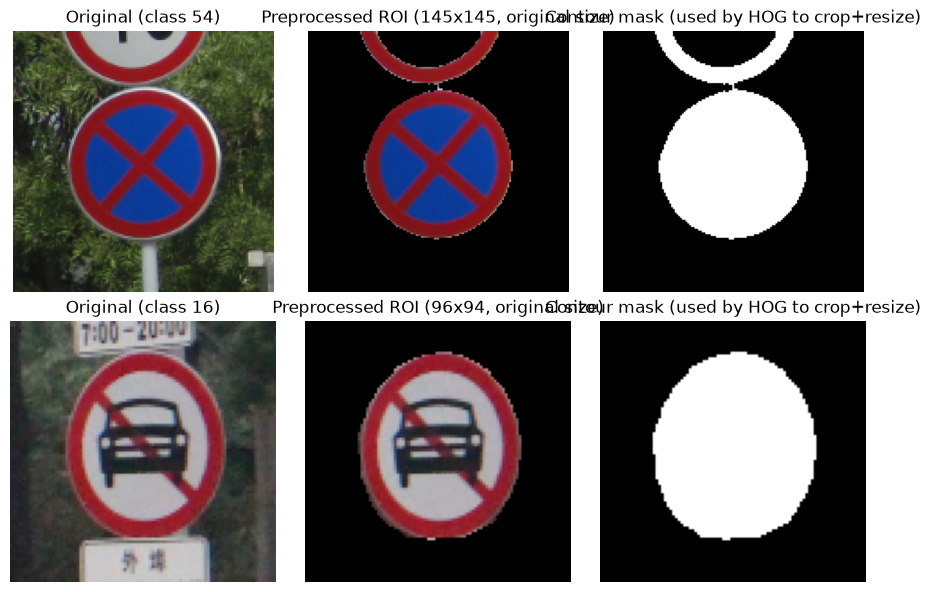

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6))

sample_indices = np.linspace(0, len(train_dataset) - 1, num=2, dtype=int).tolist()

for row, index in enumerate(sample_indices):
    image, label = train_dataset[index]
    roi = preprocessing.get_roi(np.array(image))

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"Original (class {label})")

    if roi is None:
        axes[row, 1].text(0.5, 0.5, "No ROI", ha="center", va="center")
        axes[row, 2].axis("off")
    else:
        roi_rgb, roi_mask = roi
        axes[row, 1].imshow(roi_rgb)
        axes[row, 1].set_title(f"Preprocessed ROI ({roi_rgb.shape[1]}x{roi_rgb.shape[0]}, original size)")
        axes[row, 2].imshow(roi_mask, cmap="gray")
        axes[row, 2].set_title("Contour mask (used by HOG to crop+resize)")

    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

## Extract features for each split

In [5]:
def extract_dataset(dataset, feature_fn):
    """Run pipeline.preprocessing.get_roi() + feature_fn over every image
    in dataset. Samples where no traffic-sign contour is found are dropped
    (see pipeline/preprocessing.py) - X/y/filenames stay aligned by row."""
    X, y, filenames, failed = [], [], [], []

    for index in range(len(dataset)):
        image, label = dataset[index]
        file_name = dataset.annotations.iloc[index]["file_name"]

        roi = preprocessing.get_roi(np.array(image))

        if roi is None:
            failed.append(file_name)
            continue

        roi_rgb, roi_mask = roi
        X.append(feature_fn(roi_rgb, roi_mask))
        y.append(label)
        filenames.append(file_name)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)
    filenames = np.array(filenames)

    print(f"Extracted: {len(X)} / {len(dataset)} (failed: {len(failed)})")
    if failed:
        print("No contour detected for:", failed[:10], "..." if len(failed) > 10 else "")

    return X, y, filenames

In [6]:
hog_feature_fn = lambda roi_rgb, roi_mask: features.extract_hog_features(roi_rgb, roi_mask)

X_train, y_train, train_filenames = extract_dataset(train_dataset, hog_feature_fn)
X_test, y_test, test_filenames = extract_dataset(test_dataset, hog_feature_fn)
X_held_out, y_held_out, held_out_filenames_extracted = extract_dataset(
    held_out_dataset, hog_feature_fn
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Held-out (assignment-1):", X_held_out.shape)

Extracted: 4730 / 4731 (failed: 1)
No contour detected for: ['054_0076.png'] 


Extracted: 1180 / 1183 (failed: 3)
No contour detected for: ['013_0011_j.png', '054_1_0076.png', '013_1_0011_1_j.png'] 


Extracted: 84 / 84 (failed: 0)
Train: (4730, 1764)
Test: (1180, 1764)
Held-out (assignment-1): (84, 1764)


## Save the feature files

In [7]:
paths.FEATURE_DIR.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    paths.FEATURE_DIR / "chinese_traffic_signs_hog_features_train.npz",
    X=X_train, y=y_train, filenames=train_filenames,
)
np.savez_compressed(
    paths.FEATURE_DIR / "chinese_traffic_signs_hog_features_test.npz",
    X=X_test, y=y_test, filenames=test_filenames,
)
np.savez_compressed(
    paths.FEATURE_DIR / "assignment1_test_hog_features.npz",
    X=X_held_out, y=y_held_out, filenames=held_out_filenames_extracted,
)

print("Saved HOG feature files to:", paths.FEATURE_DIR.resolve())

Saved HOG feature files to: /home/hongye/projects/traffic-sign-recognition/features


## Task 1: HOG Recognition Rate Evaluation

Assignment 2 / Task 1 asks us to identify a feature extraction technique and evaluate its
**recognition rate** - not to train or score a classifier. This section evaluates HOG as a
feature extraction technique on its own terms, over the same 84 Assignment-1 held-out
images used above (`held_out_dataset`), using the assignment's formula:

```
Recognition Rate = (Number of successfully extracted images / Total images) x 100%
```

This is deliberately **not** a classification accuracy figure - any accuracy reported in
the `03-classifier/` notebooks comes from a downstream classifier trained on HOG features,
which answers a different question (does the classifier get the label right?) than Task 1
does (does the extractor produce a usable feature vector at all?). No classifier (SVM,
Random Forest, Decision Tree, etc.) and no classification metric (accuracy, precision,
recall, F1, confusion matrix) is used in this section - it must use the same formula as the
HSV Task 1 evaluation in `02_hsv_color_histogram_chinese.ipynb`, applied to the identical 84
images, so the two are directly comparable.

**Definition of "correctly extracted".** For every one of the 84 images, we run the HOG
extraction pipeline (`pipeline.preprocessing.get_roi` followed by
`pipeline.features.extract_hog_features`) and call it a success only if **all** hold:

1. A traffic-sign contour is found, i.e. `get_roi` returns a ROI instead of `None`.
2. `extract_hog_features` runs on that ROI without raising an exception.
3. The returned feature vector is non-empty and has exactly the expected dimensionality
   for the fixed HOG canvas (`pipeline.features.expected_hog_dim()` - derived below).
4. Every value in the vector is finite (no `NaN` / `Inf`).

Any image failing any of these four checks counts as a failed extraction.

In [8]:
import pandas as pd
from skimage.feature import hog

### Expected HOG feature dimension

`extract_hog_features` crops each ROI to its mask's bounding box and resizes that crop
(Lanczos) to a fixed `features.HOG_ROI_SIZE x features.HOG_ROI_SIZE` (32x32) canvas before
running HOG with `pixels_per_cell=(4, 4)`, `cells_per_block=(2, 2)`, `orientations=9` - the
same parameters and resize target as the original deprecated notebook. This sizing happens
inside `extract_hog_features` itself, not in `pipeline.preprocessing.get_roi()` (which stays
segmentation + background removal only, shared unchanged with HSV) - so every image still
produces the same fixed dimension:

```
cells_per_side  = HOG_ROI_SIZE / pixels_per_cell     = 32 / 4 = 8
blocks_per_side = cells_per_side - cells_per_block+1 = 8 - 2 + 1 = 7
feature_dim     = blocks_per_side^2 * cells_per_block^2 * orientations
                = 7^2 * 2^2 * 9 = 1764
```

In [9]:
EXPECTED_HOG_DIM = features.expected_hog_dim()
print("Expected HOG feature dimension:", EXPECTED_HOG_DIM)

Expected HOG feature dimension: 1764


### Run HOG extraction on all 84 images and score each one

`category` is recorded for reference in the saved report only - it is never used to judge
success, since Task 1 evaluates the extractor, not a classifier.

In [10]:
def evaluate_hog_extraction(dataset, expected_dim):
    """Run the HOG extraction pipeline on every image in `dataset` and record a
    Task 1 success/failure verdict per image, keeping row order == dataset order."""
    records = []
    feature_vectors = []

    for index in range(len(dataset)):
        image, category = dataset[index]
        file_name = dataset.annotations.iloc[index]["file_name"]

        roi_found = False
        success = False
        reason = ""
        dim = 0
        vector = None

        try:
            roi = preprocessing.get_roi(np.array(image))
            if roi is None:
                reason = "No traffic-sign contour found (ROI extraction failed)"
            else:
                roi_found = True
                roi_rgb, roi_mask = roi
                vector = features.extract_hog_features(roi_rgb, roi_mask)

                if vector is None or vector.size == 0:
                    reason = "Empty HOG feature vector"
                elif vector.shape[0] != expected_dim:
                    reason = f"Unexpected HOG dimension: {vector.shape[0]} != {expected_dim}"
                elif not np.all(np.isfinite(vector)):
                    reason = "HOG feature vector contains NaN/Inf"
                else:
                    success = True
                    dim = vector.shape[0]
        except Exception as exc:
            reason = f"Exception during extraction: {exc!r}"

        records.append({
            "index": index,
            "file_name": file_name,
            "category": category,
            "roi_found": roi_found,
            "success": success,
            "dim": dim,
            "reason": reason,
        })
        feature_vectors.append(vector if success else None)

    return pd.DataFrame.from_records(records), feature_vectors


hog_task1_results, hog_task1_vectors = evaluate_hog_extraction(held_out_dataset, EXPECTED_HOG_DIM)
hog_task1_results.head()

,index,file_name,category,roi_found,success,dim,reason
0,0,001_0004.png,1,True,True,1764,
1,1,002_0036.png,2,True,True,1764,
2,2,005_0030.png,5,True,True,1764,
3,3,020_0003.png,20,True,True,1764,
4,4,020_0004.png,20,True,True,1764,


### Task 1 recognition rate report

In [11]:
hog_task1_total = len(held_out_dataset)
hog_task1_success = int(hog_task1_results["success"].sum())
hog_task1_failed = hog_task1_total - hog_task1_success
hog_task1_rate = hog_task1_success / hog_task1_total * 100

print("Total images:                ", hog_task1_total)
print("Successfully extracted:      ", hog_task1_success)
print("Failed images:                ", hog_task1_failed)
print(f"Recognition rate:              {hog_task1_rate:.2f}%")
print("HOG feature vector dimension:", EXPECTED_HOG_DIM)

if hog_task1_failed:
    print()
    print("Failed images:")
    print(hog_task1_results.loc[~hog_task1_results["success"], ["file_name", "reason"]].to_string(index=False))

Total images:                 84
Successfully extracted:       84
Failed images:                 0
Recognition rate:              100.00%
HOG feature vector dimension: 1764


### Visualize HOG extraction on example images

At least 10 examples, each showing the preprocessed ROI next to its HOG visualization
(gradient-orientation image), computed with the same parameters used for the saved feature
vectors - `hog(..., visualize=True)` is only used here for the picture; the saved feature
vectors above come from `extract_hog_features`, unchanged.

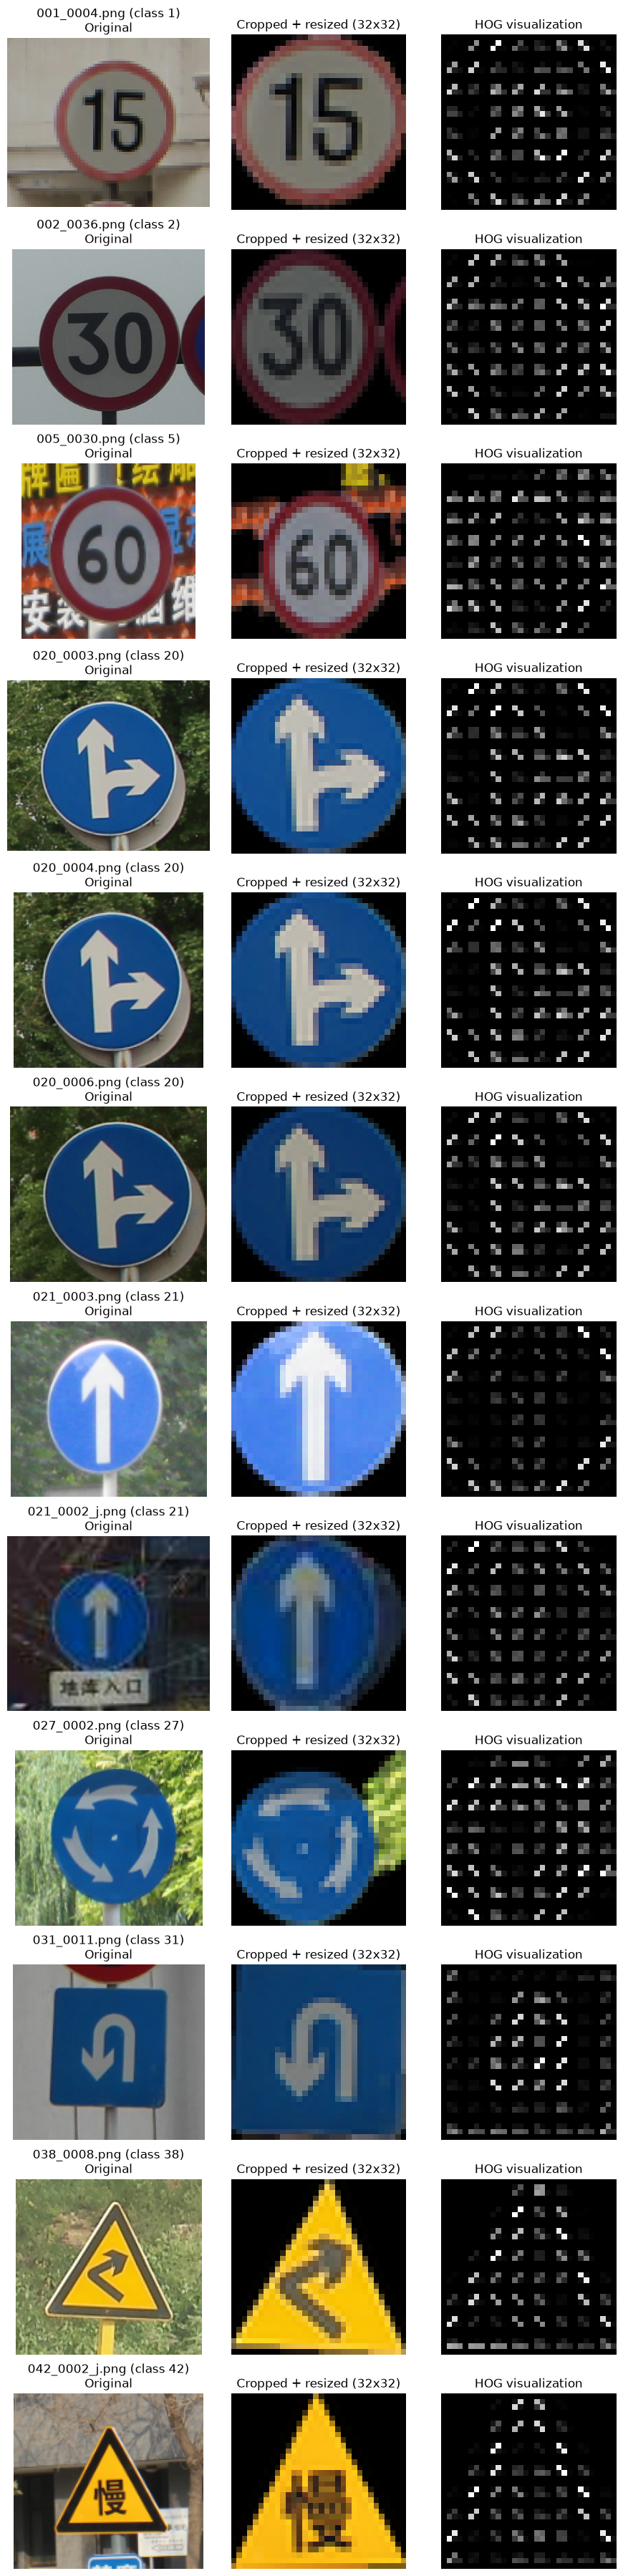

In [12]:
N_EXAMPLES = 12
hog_example_indices = hog_task1_results.loc[hog_task1_results["success"]].index[:N_EXAMPLES].tolist()

fig, axes = plt.subplots(len(hog_example_indices), 3, figsize=(9, 3 * len(hog_example_indices)))

for row, index in enumerate(hog_example_indices):
    image, category = held_out_dataset[index]
    file_name = hog_task1_results.loc[index, "file_name"]

    roi_rgb, roi_mask = preprocessing.get_roi(np.array(image))
    hog_input = features.prepare_hog_input(roi_rgb, roi_mask)
    _hog_vector, hog_image = hog(
        hog_input,
        orientations=features.HOG_ORIENTATIONS,
        pixels_per_cell=features.HOG_PIXELS_PER_CELL,
        cells_per_block=features.HOG_CELLS_PER_BLOCK,
        block_norm=features.HOG_BLOCK_NORM,
        transform_sqrt=True,
        channel_axis=-1,
        visualize=True,
    )

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"{file_name} (class {category})\nOriginal")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(hog_input)
    axes[row, 1].set_title(f"Cropped + resized ({features.HOG_ROI_SIZE}x{features.HOG_ROI_SIZE})")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(hog_image, cmap="gray")
    axes[row, 2].set_title("HOG visualization")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

### Save the Task 1 evaluation results

One artifact, index-aligned to the 84 Assignment-1 images in `held_out_df` order:

- `results/hog_task1_recognition_84.csv` - the per-image success/failure report (`file_name`,
  `category`, `success`, `dim`, and a `reason` for any failure), for side-by-side comparison
  with the HSV Task 1 report.

The feature vectors themselves are not saved again here - `assignment1_test_hog_features.npz`
(saved earlier, in "Save the feature files") already holds the successfully-extracted
vectors for these same 84 images. Alignment between the two files is by `file_name`, not
position: this CSV always has all 84 rows (success or not), while the `.npz` only ever
contains rows where `success` is True, so join on `file_name` to recover which vector
belongs to which image - do not assume the two files' row order matches if any image ever
fails (currently none do). Keeping a single feature file per split, instead of a second
copy of the vectors here, avoids two independent extraction passes over the same images
silently drifting apart.

In [13]:
paths.RESULT_DIR.mkdir(parents=True, exist_ok=True)

hog_task1_results.to_csv(paths.RESULT_DIR / "hog_task1_recognition_84.csv", index=False)

print("Saved:", paths.RESULT_DIR / "hog_task1_recognition_84.csv")

Saved: ../results/hog_task1_recognition_84.csv


### Conclusion

Using the assignment's Task 1 formula - `Recognition Rate = (successfully extracted images /
total images) x 100%` - applied to the same 84 Assignment-1 images the HSV Task 1 evaluation
uses:

- **Total images:** 84
- **Successfully extracted / Failed / Recognition rate:** see the report printed above
- **HOG feature vector dimension:** 1764 (fixed by `extract_hog_features` cropping each ROI
  to its mask's bounding box and resizing to a 32x32 canvas; `pipeline.preprocessing.get_roi()`
  itself stays untouched - it only segments and removes the background)

This HOG Task 1 recognition rate is directly comparable with the HSV Task 1 recognition rate
computed the same way in `02_hsv_color_histogram_chinese.ipynb` - independent of, and not to
be confused with, either descriptor's downstream classification accuracy.